# Lab 6 – Logistic Regression & KNN Classification
**Machine Learning — Lab Manual | BS Computer Science, 5th Semester**

| Field | Details |
|---|---|
| **Name** | Abdul Wali |
| **Student ID** | 023-24-0174 |
| **Section** | F |
| **GitHub Profile** | AWS9760 |
| **Dataset** | Telco Customer Churn (`clean_churn.csv`, the cleaned file from Lab 2) |
| **Dataset Source** | Telco Customer Churn dataset (Kaggle): https://www.kaggle.com/datasets/blastchar/telco-customer-churn |

## Setup: libraries and helpers
Imports, display options, the random seed used everywhere (same as Labs 3–4) and two small helpers for computing the four metrics used in every lab.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

RANDOM_STATE = 42

pd.options.display.float_format = '{:,.3f}'.format
pd.options.display.max_columns = None
pd.options.display.max_colwidth = None
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3})


def evaluate(y_true, y_pred):
    """The four metrics used in Labs 3-6 (positive class = churn = 1)."""
    return {'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred),
            'Recall': recall_score(y_true, y_pred),
            'F1-score': f1_score(y_true, y_pred)}


def pct(value, decimals=1):
    return f"{100 * value:.{decimals}f}%"


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn']).plot(cmap='Blues', values_format='d')
    plt.title(title)
    plt.grid(False)
    plt.show()
    return cm

## 1. Problem Definition & Dataset Verification

**Problem.** As in Labs 2–4, the task is to predict whether a Telco customer will churn (`Churn` = Yes/No) from their account, service and billing profile, so the company can contact at-risk customers before they leave. In this lab I add two new classifiers — **Logistic Regression** and **K-Nearest Neighbors (KNN)** — and, for the first time, compare **four algorithm families** (Decision Tree, Random Forest, Logistic Regression, KNN) on exactly the same split with the same four metrics: accuracy, precision, recall and F1-score.

**Task 1 — Load `clean_churn.csv` and verify its shape and dtypes.** The cell below loads the cleaned file saved in Lab 2 (if the file is missing it re-runs the Lab 2 cleaning steps on the raw Kaggle file).

In [2]:
SEARCH_DIRS = ['.', '/content', '/content/drive/MyDrive', '/content/drive/MyDrive/Colab Notebooks']
RAW_NAMES = ['WA_Fn-UseC_-Telco-Customer-Churn.xls', 'WA_Fn-UseC_-Telco-Customer-Churn.csv']


def load_clean_churn():
    """Load clean_churn.csv; fall back to re-running the Lab 2 cleaning on the raw Kaggle file."""
    for folder in SEARCH_DIRS:
        path = os.path.join(folder, 'clean_churn.csv')
        if os.path.exists(path):
            return pd.read_csv(path), path
    for folder in SEARCH_DIRS:
        for name in RAW_NAMES:
            path = os.path.join(folder, name)
            if os.path.exists(path):
                raw = pd.read_csv(path)                                            # the raw .xls is really a CSV
                clean = raw.drop(columns=['customerID']).copy()                    # Lab 2: identifier removed
                clean['TotalCharges'] = pd.to_numeric(clean['TotalCharges'], errors='coerce').fillna(0)   # 11 blanks -> 0
                clean['SeniorCitizen'] = clean['SeniorCitizen'].map({0: 'No', 1: 'Yes'})                  # 0/1 -> No/Yes
                return clean, path + '  (re-cleaned with the Lab 2 steps)'
    return None, None


df, source = load_clean_churn()
if df is None:
    try:
        from google.colab import files
        print("Upload clean_churn.csv (from Lab 2) ...")
        files.upload()
        df, source = load_clean_churn()
    except ImportError:
        pass
if df is None:
    raise FileNotFoundError("clean_churn.csv not found. Upload it to the Colab session and re-run this cell.")

print("Loaded from:", source)
print("Shape:", df.shape)
df.info()

Loaded from: ./clean_churn.csv
Shape: (7043, 20)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   str    
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  Paym

In [3]:
checks = {
    'Shape is (7043, 20), as in Labs 2-4': df.shape == (7043, 20),
    'No missing values': int(df.isnull().sum().sum()) == 0,
    'No customerID column left': 'customerID' not in df.columns,
    'Target column Churn is present': 'Churn' in df.columns,
}
for name, ok in checks.items():
    print(('OK   ' if ok else 'FAIL ') + name)
assert all(checks.values()), "The dataset does not match the cleaned file from Lab 2"

class_table = pd.DataFrame({'Customers': df['Churn'].value_counts(),
                            'Share (%)': (100 * df['Churn'].value_counts(normalize=True)).round(1)})
display(class_table)

OK   Shape is (7043, 20), as in Labs 2-4
OK   No missing values
OK   No customerID column left
OK   Target column Churn is present


,Customers,Share (%)
Churn,,
No,5174,73.500
Yes,1869,26.500


In [4]:
n_rows, n_cols = df.shape
n_num = df.select_dtypes(include='number').shape[1]
n_txt = n_cols - n_num
share_yes = (df['Churn'] == 'Yes').mean()
always_no_acc = 1 - share_yes

display(Markdown(f"""**Interpretation.** The cleaned dataset is intact: **{n_rows:,} customers and {n_cols} columns** ({n_num} numeric: `tenure`, `MonthlyCharges`, `TotalCharges`; {n_txt} text/categorical including the target `Churn`), **no missing values**, and no identifier column. The target is still imbalanced: {pct(1 - share_yes)} of customers stayed and {pct(share_yes)} churned, so a lazy model that always answers "No" would already be {pct(always_no_acc)} accurate while catching zero churners — which is why precision, recall and F1 (not accuracy alone) are used throughout this lab, exactly as in Labs 3–4.
"""))

**Interpretation.** The cleaned dataset is intact: **7,043 customers and 20 columns** (3 numeric: `tenure`, `MonthlyCharges`, `TotalCharges`; 17 text/categorical including the target `Churn`), **no missing values**, and no identifier column. The target is still imbalanced: 73.5% of customers stayed and 26.5% churned, so a lazy model that always answers "No" would already be 73.5% accurate while catching zero churners — which is why precision, recall and F1 (not accuracy alone) are used throughout this lab, exactly as in Labs 3–4.


**Task 2 — My Lab 3 and Lab 4 results (the benchmarks for today).** These are the test-set numbers recorded in my earlier notebooks (same 80/20 stratified split, `random_state=42`):

In [5]:
RECORDED = pd.DataFrame({
    'Accuracy':  [0.801, 0.805],
    'Precision': [0.667, 0.662],
    'Recall':    [0.497, 0.540],
    'F1-score':  [0.570, 0.595],
}, index=['Decision Tree (max_depth=6) - Lab 3', 'Random Forest (tuned) - Lab 4'])
display(RECORDED)

,Accuracy,Precision,Recall,F1-score
Decision Tree (max_depth=6) - Lab 3,0.801,0.667,0.497,0.570
Random Forest (tuned) - Lab 4,0.805,0.662,0.540,0.595


**Restated benchmarks.** In Lab 3 the Decision Tree limited to `max_depth=6` (gini) reached **80.1% accuracy, 66.7% precision, 49.7% recall and F1 = 0.570** on the test set, after the unrestricted baseline tree had overfitted badly (99.8% train vs. 73.2% test accuracy). In Lab 4 the Random Forest tuned with `GridSearchCV` (`n_estimators=200`, `max_depth=10`, `min_samples_split=2`) improved on it to **80.5% accuracy, 66.2% precision, 54.0% recall and F1 = 0.595**, making it my best model so far. Both models are weakest on recall for the churn class, which is the number to beat today (Lab 3's entropy-criterion tree reached F1 = 0.601 with 58.3% recall, but I use the gini depth-6 tree as the Decision Tree benchmark because that is the version Lab 4 carried forward and compared against).

## 2. Feature Scaling & Preparation

**Task 1 — Prepare X and y exactly as in Labs 3–4.** The target is encoded as 0/1 (`Yes` = 1 = churn), identifiers are dropped (none are left in the cleaned file), and every categorical column is one-hot encoded with `drop_first=True`. One-hot encoding is the right choice because none of the categorical columns (`Contract`, `InternetService`, `PaymentMethod`, ...) has a natural order, and `drop_first=True` removes the redundant dummy column of each feature (that category becomes the baseline).

In [6]:
df_model = df.copy()
if 'customerID' in df_model.columns:
    df_model = df_model.drop(columns=['customerID'])

y = df_model['Churn'].map({'No': 0, 'Yes': 1})
X = df_model.drop(columns=['Churn'])

categorical_cols = X.select_dtypes(exclude='number').columns.tolist()
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

all_numeric = all(pd.api.types.is_numeric_dtype(t) for t in X.dtypes)
print("Categorical columns encoded:", len(categorical_cols))
print("X shape:", X.shape, "| all columns numeric:", all_numeric, "| missing values:", int(X.isnull().sum().sum()))
print("y values:", y.value_counts().to_dict())
assert all_numeric and X.isnull().sum().sum() == 0 and X.shape == (7043, 30)

Categorical columns encoded: 16
X shape: (7043, 30) | all columns numeric: True | missing values: 0
y values: {0: 5174, 1: 1869}


**Task 2 — Why scaling matters for KNN and Logistic Regression but not for trees.** KNN classifies by straight-line distance, so a feature measured in the thousands (`TotalCharges`) completely swamps one measured in tens (`tenure`) or in 0/1 (the dummy columns) unless every feature is first put on a comparable scale; Logistic Regression is fitted by an iterative optimizer with an L2 penalty on the coefficients, which also behaves better — it converges faster and penalizes all features evenly — when the inputs share a scale. A Decision Tree or Random Forest only asks "is this feature above or below a threshold?", and the best threshold simply moves along with any rescaling, so its splits and predictions are identical whether `tenure` is in months or in years.

**Task 3 — Split first, then fit the scaler on the training data only.** The split is identical to Labs 3–4 (80/20, `random_state=42`, `stratify=y`), so every model today is evaluated on exactly the same 1,409 test customers.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

split_table = pd.DataFrame({
    'Shape': [str(X_train.shape), str(X_test.shape), str(y_train.shape), str(y_test.shape)],
    'Churn rate (%)': ['-', '-', f"{100 * y_train.mean():.1f}", f"{100 * y_test.mean():.1f}"],
}, index=['X_train', 'X_test', 'y_train', 'y_test'])
display(split_table)

# Fit the scaler on the TRAINING features only, then apply the same transformation to both sets
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

print("Scaled TRAIN set: largest |mean| of any column =", round(float(X_train_scaled.mean().abs().max()), 6))
print("Scaled TEST set : mean of tenure / MonthlyCharges / TotalCharges =",
      X_test_scaled[['tenure', 'MonthlyCharges', 'TotalCharges']].mean().round(3).to_dict())
print("Scaler's mean for tenure equals the TRAIN mean:", bool(np.isclose(scaler.mean_[0], X_train['tenure'].mean())),
      "| equals the FULL-data mean:", bool(np.isclose(scaler.mean_[0], X['tenure'].mean())))

,Shape,Churn rate (%)
X_train,"(5634, 30)",-
X_test,"(1409, 30)",-
y_train,"(5634,)",26.5
y_test,"(1409,)",26.5


Scaled TRAIN set: largest |mean| of any column = 0.0
Scaled TEST set : mean of tenure / MonthlyCharges / TotalCharges = {'tenure': -0.023, 'MonthlyCharges': -0.028, 'TotalCharges': -0.043}
Scaler's mean for tenure equals the TRAIN mean: True | equals the FULL-data mean: False


In [8]:
display(Markdown(f"""**Interpretation of the split.** The stratified split gives **{len(X_train):,} training** and **{len(X_test):,} test** customers with {X_train.shape[1]} feature columns each, and the churn rate is almost identical in both parts ({100 * y_train.mean():.1f}% vs. {100 * y_test.mean():.1f}%), so the test set is a fair sample. After scaling, the training columns have mean 0 (largest deviation {float(X_train_scaled.mean().abs().max()):.6f}), while the *test* columns do not have exactly mean 0 — that is the proof that the scaler's mean and standard deviation came from the training data alone and were merely *applied* to the test data.

**Why must the scaler be fitted on the training data only?** The scaler "learns" a mean and a standard deviation from whatever data it sees; if I fitted it on the full dataset (or scaled before splitting), the test customers would influence those numbers, so information from the supposedly unseen test set would leak into the training pipeline. This quiet data leakage makes test scores look slightly better than they would be on genuinely new customers. Fitting on the training set and then applying the same transformation to the test set mimics deployment, where a new customer must be scaled with statistics learned from past customers.
"""))

**Interpretation of the split.** The stratified split gives **5,634 training** and **1,409 test** customers with 30 feature columns each, and the churn rate is almost identical in both parts (26.5% vs. 26.5%), so the test set is a fair sample. After scaling, the training columns have mean 0 (largest deviation 0.000000), while the *test* columns do not have exactly mean 0 — that is the proof that the scaler's mean and standard deviation came from the training data alone and were merely *applied* to the test data.

**Why must the scaler be fitted on the training data only?** The scaler "learns" a mean and a standard deviation from whatever data it sees; if I fitted it on the full dataset (or scaled before splitting), the test customers would influence those numbers, so information from the supposedly unseen test set would leak into the training pipeline. This quiet data leakage makes test scores look slightly better than they would be on genuinely new customers. Fitting on the training set and then applying the same transformation to the test set mimics deployment, where a new customer must be scaled with statistics learned from past customers.


In [9]:
# What scaling actually changed
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
before = X_train[num_cols].agg(['min', 'max', 'std']).T
before.columns = ['Min (raw)', 'Max (raw)', 'Std dev (raw)']
after = X_train_scaled[num_cols].agg(['mean', 'std']).T
after.columns = ['Mean (scaled)', 'Std dev (scaled)']
display(pd.concat([before, after], axis=1))

# Share of the squared distance KNN computes that each feature drives:
# for two random customers E[(x - x')^2] = 2 * variance, so a feature's share is its variance / total variance
var_raw = X_train.astype(float).var()
share_raw = var_raw / var_raw.sum()
n_features = X_train.shape[1]
raw_shares = [100 * share_raw[c] for c in num_cols] + [100 * share_raw.drop(num_cols).sum()]
scaled_shares = [100 / n_features] * 3 + [100 * (n_features - 3) / n_features]
share_table = pd.DataFrame({
    'Share of KNN distance - raw features (%)': [f"{v:.4f}" for v in raw_shares],
    'Share of KNN distance - scaled features (%)': [f"{v:.2f}" for v in scaled_shares],
}, index=num_cols + [f'{n_features - 3} dummy columns (combined)'])
display(share_table)

,Min (raw),Max (raw),Std dev (raw),Mean (scaled),Std dev (scaled)
tenure,0.000,72.000,24.569,-0.000,1.000
MonthlyCharges,18.400,118.750,30.138,-0.000,1.000
TotalCharges,0.000,"8,684.800","2,279.204",0.000,1.000


,Share of KNN distance - raw features (%),Share of KNN distance - scaled features (%)
tenure,0.0116,3.33
MonthlyCharges,0.0175,3.33
TotalCharges,99.9708,3.33
27 dummy columns (combined),0.0001,90.00


In [10]:
tc_share = share_raw['TotalCharges']
dummy_share = share_raw.drop(num_cols).sum()
dummy_share_txt = 'under 0.001%' if dummy_share < 0.00001 else pct(dummy_share, 3)
display(Markdown(f"""**Interpretation.** On the raw scale the three numeric features span very different ranges: `tenure` runs 0–{X_train['tenure'].max():.0f}, `MonthlyCharges` roughly {X_train['MonthlyCharges'].min():.0f}–{X_train['MonthlyCharges'].max():.0f}, and `TotalCharges` 0–{X_train['TotalCharges'].max():,.0f}. Because KNN's distance is driven by variance, `TotalCharges` alone would account for about **{pct(tc_share, 2)}** of the distance between two customers, whereas the {n_features - 3} dummy columns together would count for only {dummy_share_txt} — in effect KNN would be a nearest-neighbor search on `TotalCharges` and nothing else. After standardization every feature has mean 0 and standard deviation 1, so each of the {n_features} columns contributes equally (about {100 / n_features:.1f}% each) and the neighbors reflect the whole customer profile.
"""))

**Interpretation.** On the raw scale the three numeric features span very different ranges: `tenure` runs 0–72, `MonthlyCharges` roughly 18–119, and `TotalCharges` 0–8,685. Because KNN's distance is driven by variance, `TotalCharges` alone would account for about **99.97%** of the distance between two customers, whereas the 27 dummy columns together would count for only under 0.001% — in effect KNN would be a nearest-neighbor search on `TotalCharges` and nothing else. After standardization every feature has mean 0 and standard deviation 1, so each of the 30 columns contributes equally (about 3.3% each) and the neighbors reflect the whole customer profile.


## 3. Logistic Regression
Logistic Regression is trained on the **scaled** features and evaluated exactly like the Decision Tree and Random Forest in Labs 3–4: accuracy, precision, recall, F1 and the confusion matrix. (It uses scikit-learn's default L2 regularization.)

,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.807,0.658,0.567,0.609


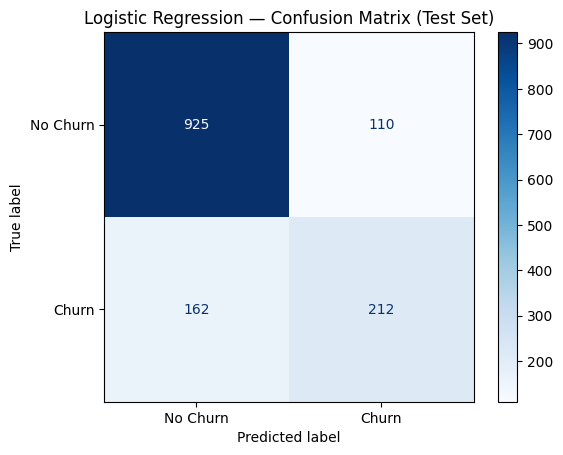

[[925 110]
 [162 212]]


In [11]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
pred_lr = log_reg.predict(X_test_scaled)

lr_metrics = pd.DataFrame([evaluate(y_test, pred_lr)], index=['Logistic Regression'])
display(lr_metrics)

cm_lr = plot_confusion(y_test, pred_lr, 'Logistic Regression — Confusion Matrix (Test Set)')
print(cm_lr)

In [12]:
tn, fp, fn, tp = cm_lr.ravel()
m = lr_metrics.iloc[0]
display(Markdown(f"""**Interpretation.** On the test set Logistic Regression reaches **{pct(m['Accuracy'])} accuracy, {pct(m['Precision'])} precision, {pct(m['Recall'])} recall and F1 = {m['F1-score']:.3f}**. The confusion matrix shows what that means for the business: of the {tp + fn} customers who really churned, the model caught **{tp}** and missed **{fn}**, and it raised **{fp}** false alarms among the {tn + fp} customers who stayed. Accuracy of {pct(m['Accuracy'])} looks impressive but is only {100 * (m['Accuracy'] - always_no_acc):.1f} points above the "always No" baseline ({pct(always_no_acc)}), so the real story is in recall — roughly {pct(fn / (tp + fn), 0)} of churners still slip through — and in precision, since about {pct(fp / (tp + fp), 0)} of the customers flagged as at-risk would not have left anyway. How this compares with the tree models is analysed in Section 5.
"""))

**Interpretation.** On the test set Logistic Regression reaches **80.7% accuracy, 65.8% precision, 56.7% recall and F1 = 0.609**. The confusion matrix shows what that means for the business: of the 374 customers who really churned, the model caught **212** and missed **162**, and it raised **110** false alarms among the 1035 customers who stayed. Accuracy of 80.7% looks impressive but is only 7.2 points above the "always No" baseline (73.5%), so the real story is in recall — roughly 43% of churners still slip through — and in precision, since about 34% of the customers flagged as at-risk would not have left anyway. How this compares with the tree models is analysed in Section 5.


In [13]:
# predict_proba for a handful of test customers
proba = log_reg.predict_proba(X_test_scaled)
print("Class order in predict_proba columns:", [int(k) for k in log_reg.classes_], "(0 = No churn, 1 = Churn)")
p_churn = pd.Series(proba[:, 1], index=X_test.index)

picked = []
for idx in p_churn.nlargest(2).index:
    picked.append((idx, 'Most likely to churn'))
for idx in (p_churn - 0.5).abs().nsmallest(4).index:
    picked.append((idx, 'Close to the 0.5 cut-off'))
for idx in p_churn.nsmallest(2).index:
    picked.append((idx, 'Least likely to churn'))

proba_table = pd.DataFrame({
    'Why shown': [why for _, why in picked],
    'Actual': [('Yes' if y_test.loc[idx] == 1 else 'No') for idx, _ in picked],
    'P(No churn)': [1 - p_churn.loc[idx] for idx, _ in picked],
    'P(Churn)': [p_churn.loc[idx] for idx, _ in picked],
    'predict() says': [('Yes' if p_churn.loc[idx] >= 0.5 else 'No') for idx, _ in picked],
}, index=[idx for idx, _ in picked])
proba_table.index.name = 'Test customer (row index)'
display(proba_table)

same = bool(np.array_equal((proba[:, 1] >= 0.5).astype(int), pred_lr))
print("predict() equals 'P(Churn) >= 0.5' for all", len(pred_lr), "test customers:", same)

Class order in predict_proba columns: [0, 1] (0 = No churn, 1 = Churn)


,Why shown,Actual,P(No churn),P(Churn),predict() says
Test customer (row index),,,,,
3380,Most likely to churn,Yes,0.145,0.855,Yes
6866,Most likely to churn,Yes,0.169,0.831,Yes
1607,Close to the 0.5 cut-off,Yes,0.500,0.500,Yes
2305,Close to the 0.5 cut-off,No,0.500,0.500,Yes
717,Close to the 0.5 cut-off,No,0.499,0.501,Yes
4537,Close to the 0.5 cut-off,No,0.501,0.499,No
2338,Least likely to churn,No,0.998,0.002,No
1824,Least likely to churn,No,0.998,0.002,No


predict() equals 'P(Churn) >= 0.5' for all 1409 test customers: True


In [14]:
above = p_churn[p_churn >= 0.5].idxmin()
below = p_churn[p_churn < 0.5].idxmax()
display(Markdown(f"""**Interpretation.** `predict_proba` returns, for every customer, the model's estimated probability of each class — column 0 is P(No churn) and column 1 is P(Churn), and each row sums to 1 (they come from passing the model's linear score through the sigmoid function). `predict()` then simply applies a **0.5 cut-off** to P(Churn): at or above 0.5 the customer is labelled Yes (1), below it No (0) — I verified that this reproduces `predict()` exactly for all {len(pred_lr):,} test customers ({same}). For example, customer {above} (P(Churn) = {p_churn.loc[above]:.3f}) is labelled Yes while customer {below} (P(Churn) = {p_churn.loc[below]:.3f}) is labelled No, although the model sees both as almost a coin flip — the cut-off is a choice, and lowering it would trade precision for more recall.
"""))

**Interpretation.** `predict_proba` returns, for every customer, the model's estimated probability of each class — column 0 is P(No churn) and column 1 is P(Churn), and each row sums to 1 (they come from passing the model's linear score through the sigmoid function). `predict()` then simply applies a **0.5 cut-off** to P(Churn): at or above 0.5 the customer is labelled Yes (1), below it No (0) — I verified that this reproduces `predict()` exactly for all 1,409 test customers (True). For example, customer 1607 (P(Churn) = 0.500) is labelled Yes while customer 4537 (P(Churn) = 0.499) is labelled No, although the model sees both as almost a coin flip — the cut-off is a choice, and lowering it would trade precision for more recall.


## 4. KNN & Choosing K
K controls KNN's complexity the way `max_depth` controlled the Decision Tree: a very small K follows individual noisy neighbors and overfits, a very large K averages over many unrelated customers and underfits. KNN is trained on the **scaled** features.

I test the lab's suggested values (1, 3, 5, 7, 9, 11, 15, 21) **plus larger values (31, 41, 51, 75, 101)** — the reason is explained below the results. For each K the table records train and test accuracy, test F1, and a 5-fold cross-validated F1 computed **on the training data only** (the scaler sits inside a pipeline so every fold fits its own scaler). K is chosen from that cross-validated score, so the test set is never used to pick K.

In [15]:
K_VALUES = [1, 3, 5, 7, 9, 11, 15, 21, 31, 41, 51, 75, 101]

rows = []
for k in K_VALUES:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train_scaled, y_train)
    train_pred = knn.predict(X_train_scaled)
    test_pred = knn.predict(X_test_scaled)
    cv_f1 = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)),
                            X_train, y_train, cv=5, scoring='f1')
    rows.append({'K': k,
                 'Train accuracy': accuracy_score(y_train, train_pred),
                 'Test accuracy': accuracy_score(y_test, test_pred),
                 'Test F1': f1_score(y_test, test_pred),
                 'CV F1 (train only)': cv_f1.mean(),
                 'CV F1 std': cv_f1.std()})

knn_results = pd.DataFrame(rows)
CHOSEN_K = int(knn_results.loc[knn_results['CV F1 (train only)'].idxmax(), 'K'])   # best cross-validated F1

knn_display = knn_results.copy()
knn_display['Chosen'] = np.where(knn_display['K'] == CHOSEN_K, '<-- chosen', '')
display(knn_display.set_index('K'))

,Train accuracy,Test accuracy,Test F1,CV F1 (train only),CV F1 std,Chosen
K,,,,,,
1,0.998,0.716,0.476,0.482,0.011,
3,0.855,0.744,0.513,0.515,0.014,
5,0.834,0.747,0.512,0.537,0.021,
7,0.827,0.759,0.532,0.554,0.022,
9,0.819,0.769,0.558,0.568,0.017,
11,0.815,0.774,0.562,0.572,0.018,
15,0.813,0.770,0.555,0.584,0.018,
21,0.809,0.771,0.562,0.592,0.020,
31,0.805,0.772,0.569,0.606,0.029,


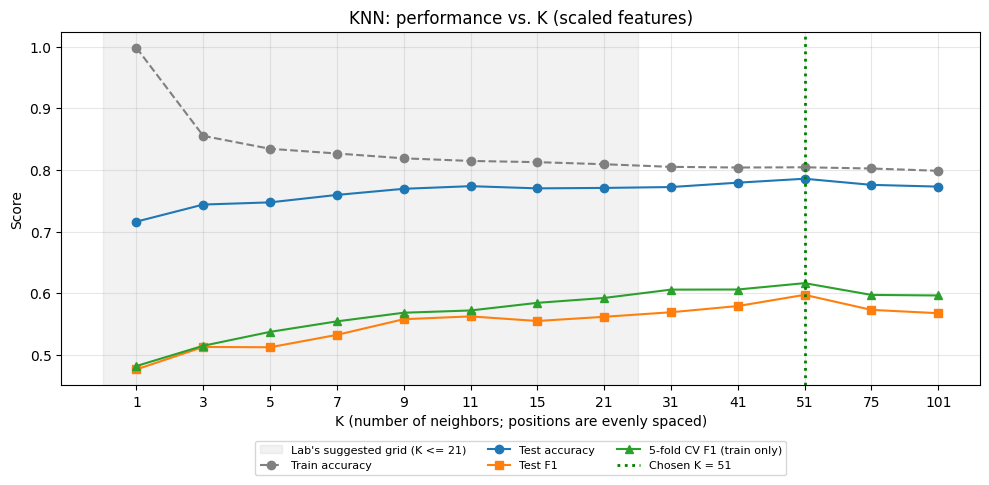

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
pos = np.arange(len(K_VALUES))
ax.axvspan(-0.5, K_VALUES.index(21) + 0.5, color='grey', alpha=0.10, label="Lab's suggested grid (K <= 21)")
ax.plot(pos, knn_results['Train accuracy'], marker='o', ls='--', color='grey', label='Train accuracy')
ax.plot(pos, knn_results['Test accuracy'], marker='o', label='Test accuracy')
ax.plot(pos, knn_results['Test F1'], marker='s', label='Test F1')
ax.plot(pos, knn_results['CV F1 (train only)'], marker='^', label='5-fold CV F1 (train only)')
ax.axvline(K_VALUES.index(CHOSEN_K), color='green', ls=':', lw=2, label=f'Chosen K = {CHOSEN_K}')
ax.set_xticks(pos)
ax.set_xticklabels(K_VALUES)
ax.set_xlabel('K (number of neighbors; positions are evenly spaced)')
ax.set_ylabel('Score')
ax.set_title('KNN: performance vs. K (scaled features)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

In [17]:
row_chosen = knn_results.loc[knn_results['K'] == CHOSEN_K].iloc[0]
row_first = knn_results.iloc[0]
row_last = knn_results.iloc[-1]
row_21 = knn_results.loc[knn_results['K'] == 21].iloc[0]
acc_peak_k = int(knn_results.loc[knn_results['Test accuracy'].idxmax(), 'K'])
f1_peak_k = int(knn_results.loc[knn_results['Test F1'].idxmax(), 'K'])

extended_txt = ""
if CHOSEN_K > 21:
    extended_txt = (f" **Why I went beyond the suggested grid.** At K = 21 the cross-validated F1 ({row_21['CV F1 (train only)']:.3f}) was still climbing, so the best K is not inside the suggested range of 1–21; "
                    f"extending the grid to 31, 41, 51, 75 and 101 shows that the curve finally peaks at K = {CHOSEN_K} and then falls back.")

if CHOSEN_K in (K_VALUES[0], K_VALUES[-1]):
    edge_txt = " Note that the chosen K sits at the edge of the grid, so a wider grid would be needed to be sure."
else:
    edge_txt = ""

agree_txt = ("The test-set curves agree: both test accuracy and test F1 also peak at this K."
             if (acc_peak_k == CHOSEN_K and f1_peak_k == CHOSEN_K) else
             f"The test-set curves point to a similar region (test accuracy peaks at K = {acc_peak_k}, test F1 at K = {f1_peak_k}).")

display(Markdown(f"""**Interpretation of the table and plot.** At **K = 1** the model memorizes its training data — {pct(row_first['Train accuracy'])} train accuracy against only {pct(row_first['Test accuracy'])} on the test set, a gap of {100 * (row_first['Train accuracy'] - row_first['Test accuracy']):.0f} points — because every prediction hangs on a single, possibly noisy neighbor. As K grows the vote averages over more customers, noise is smoothed out, the train/test gap shrinks and both F1 curves rise.{extended_txt}

**My choice: K = {CHOSEN_K}.** It has the highest cross-validated F1 on the training data ({row_chosen['CV F1 (train only)']:.3f} ± {row_chosen['CV F1 std']:.3f}), and at this K the test set gives {pct(row_chosen['Test accuracy'])} accuracy and F1 = {row_chosen['Test F1']:.3f}. {agree_txt} I do **not** choose the smallest value (K = 1) because it overfits as shown above, and I do not choose the largest value (K = {K_VALUES[-1]}) because by then the cross-validated F1 has fallen back to {row_last['CV F1 (train only)']:.3f} and test F1 to {row_last['Test F1']:.3f}: the vote averages over so many unrelated customers that local patterns are blurred (underfitting).{edge_txt} Because K was picked using the training data only, the test metrics below are an honest estimate; the test columns for the other K values are shown only to illustrate the shape of the curve.
"""))

**Interpretation of the table and plot.** At **K = 1** the model memorizes its training data — 99.8% train accuracy against only 71.6% on the test set, a gap of 28 points — because every prediction hangs on a single, possibly noisy neighbor. As K grows the vote averages over more customers, noise is smoothed out, the train/test gap shrinks and both F1 curves rise. **Why I went beyond the suggested grid.** At K = 21 the cross-validated F1 (0.592) was still climbing, so the best K is not inside the suggested range of 1–21; extending the grid to 31, 41, 51, 75 and 101 shows that the curve finally peaks at K = 51 and then falls back.

**My choice: K = 51.** It has the highest cross-validated F1 on the training data (0.616 ± 0.028), and at this K the test set gives 78.6% accuracy and F1 = 0.597. The test-set curves agree: both test accuracy and test F1 also peak at this K. I do **not** choose the smallest value (K = 1) because it overfits as shown above, and I do not choose the largest value (K = 101) because by then the cross-validated F1 has fallen back to 0.596 and test F1 to 0.568: the vote averages over so many unrelated customers that local patterns are blurred (underfitting). Because K was picked using the training data only, the test metrics below are an honest estimate; the test columns for the other K values are shown only to illustrate the shape of the curve.


,Accuracy,Precision,Recall,F1-score
KNN (K=51),0.786,0.596,0.599,0.597


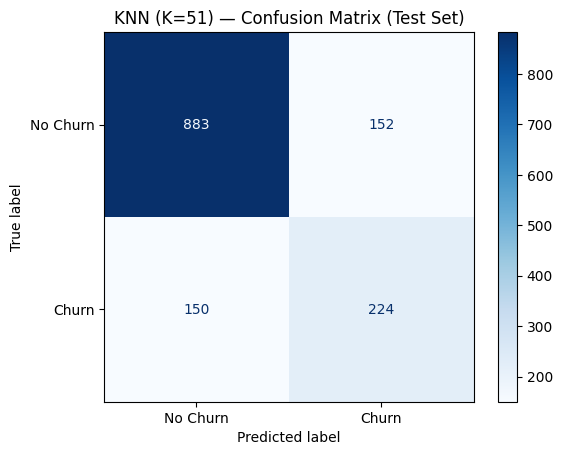

[[883 152]
 [150 224]]


In [18]:
knn_final = KNeighborsClassifier(n_neighbors=CHOSEN_K)
knn_final.fit(X_train_scaled, y_train)
pred_knn = knn_final.predict(X_test_scaled)

knn_metrics = pd.DataFrame([evaluate(y_test, pred_knn)], index=[f'KNN (K={CHOSEN_K})'])
display(knn_metrics)

cm_knn = plot_confusion(y_test, pred_knn, f'KNN (K={CHOSEN_K}) — Confusion Matrix (Test Set)')
print(cm_knn)

In [19]:
tn_k, fp_k, fn_k, tp_k = cm_knn.ravel()
mk = knn_metrics.iloc[0]
display(Markdown(f"""**Interpretation.** With K = {CHOSEN_K} the final KNN model scores **{pct(mk['Accuracy'])} accuracy, {pct(mk['Precision'])} precision, {pct(mk['Recall'])} recall and F1 = {mk['F1-score']:.3f}** on the test set. It catches **{tp_k}** of the {tp_k + fn_k} actual churners and misses {fn_k}, at the cost of {fp_k} false alarms. Compared with Logistic Regression ({pct(m['Recall'])} recall, {pct(m['Precision'])} precision) the KNN model {'finds more of the churners but is less precise' if (mk['Recall'] > m['Recall'] and mk['Precision'] < m['Precision']) else 'has a different recall/precision balance'}, which is the kind of trade-off the model comparison in Section 5 looks at.
"""))

**Interpretation.** With K = 51 the final KNN model scores **78.6% accuracy, 59.6% precision, 59.9% recall and F1 = 0.597** on the test set. It catches **224** of the 374 actual churners and misses 150, at the cost of 152 false alarms. Compared with Logistic Regression (56.7% recall, 65.8% precision) the KNN model finds more of the churners but is less precise, which is the kind of trade-off the model comparison in Section 5 looks at.


## 5. Model Comparison (4 Models)
All four classifiers are now evaluated **on the same 1,409 test customers** with the same four metrics. The Decision Tree and Random Forest are retrained here with the exact settings from Labs 3–4 (on the unscaled features — scaling does not affect trees); Logistic Regression and KNN use the scaled features. I also check that the retrained models reproduce the numbers recorded in my earlier labs.

In [20]:
dt_model = DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE).fit(X_train, y_train)
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=2,
                                  random_state=RANDOM_STATE).fit(X_train, y_train)
pred_dt = dt_model.predict(X_test)
pred_rf = rf_model.predict(X_test)

NAME_DT, NAME_RF, NAME_LR = 'Decision Tree (max_depth=6)', 'Random Forest (tuned)', 'Logistic Regression'
NAME_KNN = f'KNN (K={CHOSEN_K})'

predictions = {NAME_DT: pred_dt, NAME_RF: pred_rf, NAME_LR: pred_lr, NAME_KNN: pred_knn}
comparison = pd.DataFrame([evaluate(y_test, p) for p in predictions.values()], index=list(predictions))
display(comparison)

# Do the retrained models reproduce my recorded Lab 3 / Lab 4 numbers?
dt_ok = np.allclose(comparison.loc[NAME_DT].round(3).values, RECORDED.iloc[0].values, atol=0.0015)
rf_ok = np.allclose(comparison.loc[NAME_RF].round(3).values, RECORDED.iloc[1].values, atol=0.0015)
print("Retrained Decision Tree matches the Lab 3 numbers:", bool(dt_ok))
print("Retrained Random Forest matches the Lab 4 numbers:", bool(rf_ok))

,Accuracy,Precision,Recall,F1-score
Decision Tree (max_depth=6),0.801,0.667,0.497,0.570
Random Forest (tuned),0.805,0.662,0.540,0.595
Logistic Regression,0.807,0.658,0.567,0.609
KNN (K=51),0.786,0.596,0.599,0.597


Retrained Decision Tree matches the Lab 3 numbers: True
Retrained Random Forest matches the Lab 4 numbers: True


In [21]:
# Best model per metric, ranks, and what each model does with the churners
best_per_metric = pd.DataFrame({'Best model': [comparison[c].idxmax() for c in comparison.columns],
                                'Score': [comparison[c].max() for c in comparison.columns]}, index=comparison.columns)
display(best_per_metric)

display(comparison.rank(ascending=False, method='min').astype(int).rename_axis(None).add_prefix('Rank: '))

error_rows = []
for name, p in predictions.items():
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test, p).ravel()
    error_rows.append({'Churners caught (TP)': tp_, 'Churners missed (FN)': fn_, 'False alarms (FP)': fp_})
display(pd.DataFrame(error_rows, index=list(predictions)))

,Best model,Score
Accuracy,Logistic Regression,0.807
Precision,Decision Tree (max_depth=6),0.667
Recall,KNN (K=51),0.599
F1-score,Logistic Regression,0.609


,Rank: Accuracy,Rank: Precision,Rank: Recall,Rank: F1-score
Decision Tree (max_depth=6),3,1,4,4
Random Forest (tuned),2,2,3,3
Logistic Regression,1,3,2,1
KNN (K=51),4,4,1,2


,Churners caught (TP),Churners missed (FN),False alarms (FP)
Decision Tree (max_depth=6),186,188,93
Random Forest (tuned),202,172,103
Logistic Regression,212,162,110
KNN (K=51),224,150,152


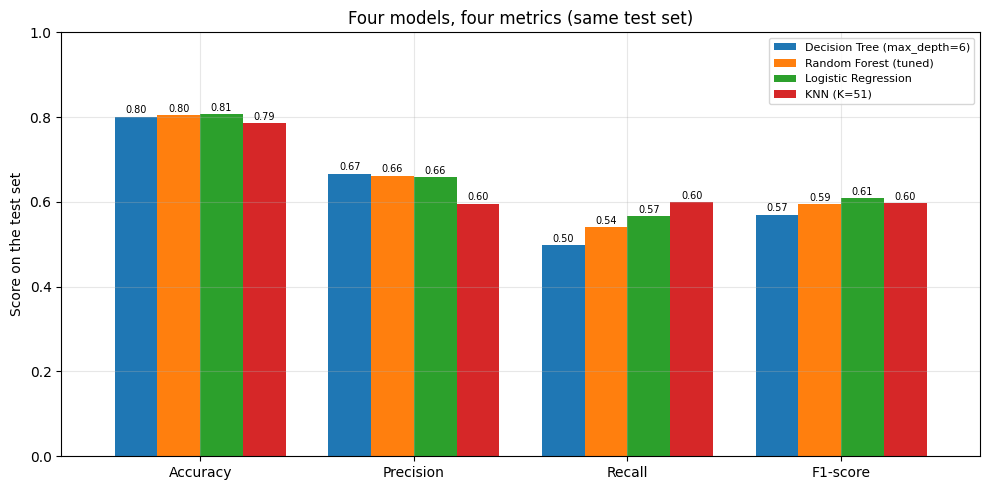

In [22]:
ax = comparison.T.plot(kind='bar', figsize=(10, 5), width=0.8, rot=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=7, padding=1)
ax.set_ylim(0, 1)
ax.set_ylabel('Score on the test set')
ax.set_title('Four models, four metrics (same test set)')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

In [23]:
winners = {metric: comparison[metric].idxmax() for metric in comparison.columns}
n_distinct = len(set(winners.values()))
overall = winners['F1-score']
acc_span = comparison['Accuracy'].max() - comparison['Accuracy'].min()
f1_span = comparison['F1-score'].max() - comparison['F1-score'].min()
rec_span = comparison['Recall'].max() - comparison['Recall'].min()
winner_txt = "; ".join(f"**{metric}** — {name} ({comparison.loc[name, metric]:.3f})" for metric, name in winners.items())
churn_caught = {n: int(confusion_matrix(y_test, p).ravel()[3]) for n, p in predictions.items()}
repro_txt = ("The retrained Decision Tree and Random Forest reproduce my Lab 3 and Lab 4 numbers exactly, so the comparison is consistent with my earlier work."
             if (dt_ok and rf_ok) else
             "The retrained trees differ slightly from my recorded Lab 3/4 numbers (probably a library-version difference), so the table above uses the freshly retrained values.")

if n_distinct == 1:
    change_txt = f"**No — {overall} wins on all four metrics.**"
else:
    change_txt = (f"**Yes, the ranking depends on the metric.** {overall} is best on F1, but "
                  + ", ".join(f"{name} is best on {metric.lower()}" for metric, name in winners.items() if name != overall)
                  + ", so the 'best' model changes with what I prioritize.")

display(Markdown(f"""**Which model performs best overall?** The best model per metric is: {winner_txt}. On the metric that balances precision and recall, **{overall}** comes out on top (F1 = {comparison.loc[overall, 'F1-score']:.3f}), ahead of the tuned Random Forest from Lab 4 ({comparison.loc[NAME_RF, 'F1-score']:.3f}) and well ahead of the single Decision Tree ({comparison.loc[NAME_DT, 'F1-score']:.3f}). {repro_txt}

**Does the ranking change with the metric?** {change_txt} For instance, the model that catches the most churners is {max(churn_caught, key=churn_caught.get)} ({max(churn_caught.values())} of {tp + fn}), while the most precise model, {winners['Precision']}, raises the fewest false alarms.

**Which metric should carry the most weight?** Because of the class imbalance from Lab 2 (a model that always says "No" is already {pct(always_no_acc)} accurate), accuracy cannot separate the models — the four accuracies span only {100 * acc_span:.1f} points, whereas F1 spans {100 * f1_span:.1f} and recall {100 * rec_span:.1f} points. For a retention campaign a missed churner (false negative) is a lost customer nobody follows up with, while a false alarm only wastes a retention offer, so **recall on the churn class matters most**; precision keeps the campaign affordable, and **F1** is the single number that balances both, so I give F1 the most weight with recall as the tie-breaker. Gaps of one or two points between models are within the noise of a single split, which is why Section 7 checks the ranking with cross-validation before choosing a final model.
"""))

**Which model performs best overall?** The best model per metric is: **Accuracy** — Logistic Regression (0.807); **Precision** — Decision Tree (max_depth=6) (0.667); **Recall** — KNN (K=51) (0.599); **F1-score** — Logistic Regression (0.609). On the metric that balances precision and recall, **Logistic Regression** comes out on top (F1 = 0.609), ahead of the tuned Random Forest from Lab 4 (0.595) and well ahead of the single Decision Tree (0.570). The retrained Decision Tree and Random Forest reproduce my Lab 3 and Lab 4 numbers exactly, so the comparison is consistent with my earlier work.

**Does the ranking change with the metric?** **Yes, the ranking depends on the metric.** Logistic Regression is best on F1, but Decision Tree (max_depth=6) is best on precision, KNN (K=51) is best on recall, so the 'best' model changes with what I prioritize. For instance, the model that catches the most churners is KNN (K=51) (224 of 374), while the most precise model, Decision Tree (max_depth=6), raises the fewest false alarms.

**Which metric should carry the most weight?** Because of the class imbalance from Lab 2 (a model that always says "No" is already 73.5% accurate), accuracy cannot separate the models — the four accuracies span only 2.1 points, whereas F1 spans 4.0 and recall 10.2 points. For a retention campaign a missed churner (false negative) is a lost customer nobody follows up with, while a false alarm only wastes a retention offer, so **recall on the churn class matters most**; precision keeps the campaign affordable, and **F1** is the single number that balances both, so I give F1 the most weight with recall as the tie-breaker. Gaps of one or two points between models are within the noise of a single split, which is why Section 7 checks the ranking with cross-validation before choosing a final model.


## 6. Coefficient Interpretation
Logistic Regression's coefficients are directly readable, but they describe **log-odds**, not a price or unit effect. Exponentiating a coefficient gives an **odds ratio**: the factor by which the odds of churning (P(churn) / P(stay)) are multiplied when the feature increases by one unit, holding the other features constant. An odds ratio above 1 raises the odds of churning, below 1 lowers them.

Because the model was trained on **standardized** features, `exp(coefficient)` is the odds ratio for a **+1 standard deviation** change. To read the effect in the original units (0 → 1 for a dummy column, one month of tenure, one dollar of charges) I divide each coefficient by the scaler's standard deviation first; both versions are shown.

In [24]:
coef_scaled = log_reg.coef_[0]
coef_original = coef_scaled / scaler.scale_          # coefficient per ORIGINAL unit
BASELINE = {c: sorted(df_model[c].unique())[0] for c in categorical_cols}     # category dropped by drop_first=True
NO_INTERNET_GROUP = [c for c in X.columns if c.endswith('No internet service')] + ['InternetService_No']
PHONE_PAIR = ['PhoneService_Yes', 'MultipleLines_No phone service']


def odds_phrase(odds_ratio):
    if odds_ratio >= 1:
        return f"{odds_ratio:.2f}x the odds (about {100 * (odds_ratio - 1):.0f}% higher)"
    return f"{odds_ratio:.2f}x the odds (about {100 * (1 - odds_ratio):.0f}% lower)"


def interpret(feature, coef_sc, coef_orig):
    unit_or = float(np.exp(coef_orig))
    if feature == 'tenure':
        return (f"Each extra month of tenure multiplies the odds of churning by {unit_or:.3f} "
                f"(about {unit_or ** 12:.2f}x per extra year), holding the other features constant.")
    if feature == 'MonthlyCharges':
        return f"Each extra 10 USD of monthly charges multiplies the odds of churning by {unit_or ** 10:.2f}, holding the other features constant."
    if feature == 'TotalCharges':
        return f"Each extra 1,000 USD of total charges multiplies the odds of churning by {unit_or ** 1000:.2f}, holding the other features constant."
    group, level = feature.split('_', 1)
    note = ''
    if feature in NO_INTERNET_GROUP:
        note = ' [identical to 6 other columns: the effect is shared, read the group together]'
    elif feature in PHONE_PAIR:
        note = ' [redundant pair with the other phone column: read together]'
    if level == 'Yes':
        return f"Customers with {group} = Yes have {odds_phrase(unit_or)} of churning than those with {group} = No, other features constant.{note}"
    return f"Customers with {group} = {level} have {odds_phrase(unit_or)} of churning than those with {group} = {BASELINE[group]}, other features constant.{note}"


coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coef_scaled,
    'Odds Ratio': np.exp(coef_scaled),
    'Odds Ratio (original unit)': np.exp(coef_original),
})
coef_df['Interpretation'] = [interpret(f, c, o) for f, c, o in zip(coef_df['Feature'], coef_scaled, coef_original)]
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False, kind='stable').index).reset_index(drop=True)

print(f"Intercept (log-odds of churn for an 'average' customer): {log_reg.intercept_[0]:.3f}")
display(coef_df)

Intercept (log-odds of churn for an 'average' customer): -1.705


,Feature,Coefficient,Odds Ratio,Odds Ratio (original unit),Interpretation
0,tenure,-1.237,0.290,0.951,"Each extra month of tenure multiplies the odds of churning by 0.951 (about 0.55x per extra year), holding the other features constant."
1,MonthlyCharges,-0.920,0.398,0.970,"Each extra 10 USD of monthly charges multiplies the odds of churning by 0.74, holding the other features constant."
2,InternetService_Fiber optic,0.776,2.173,4.775,"Customers with InternetService = Fiber optic have 4.77x the odds (about 377% higher) of churning than those with InternetService = DSL, other features constant."
3,Contract_Two year,-0.587,0.556,0.254,"Customers with Contract = Two year have 0.25x the odds (about 75% lower) of churning than those with Contract = Month-to-month, other features constant."
4,TotalCharges,0.514,1.672,1.000,"Each extra 1,000 USD of total charges multiplies the odds of churning by 1.25, holding the other features constant."
5,Contract_One year,-0.286,0.752,0.495,"Customers with Contract = One year have 0.50x the odds (about 50% lower) of churning than those with Contract = Month-to-month, other features constant."
6,StreamingMovies_Yes,0.257,1.293,1.694,"Customers with StreamingMovies = Yes have 1.69x the odds (about 69% higher) of churning than those with StreamingMovies = No, other features constant."
7,StreamingTV_Yes,0.257,1.293,1.694,"Customers with StreamingTV = Yes have 1.69x the odds (about 69% higher) of churning than those with StreamingTV = No, other features constant."
8,MultipleLines_Yes,0.216,1.241,1.549,"Customers with MultipleLines = Yes have 1.55x the odds (about 55% higher) of churning than those with MultipleLines = No, other features constant."
9,PaperlessBilling_Yes,0.182,1.200,1.448,"Customers with PaperlessBilling = Yes have 1.45x the odds (about 45% higher) of churning than those with PaperlessBilling = No, other features constant."


In [25]:
c = coef_df.set_index('Feature')
orr = lambda f: float(c.loc[f, 'Odds Ratio (original unit)'])
ten_year = orr('tenure') ** 12
ten_year_txt = f"{100 * abs(1 - ten_year):.0f}% {'lower' if ten_year < 1 else 'higher'} odds for each extra year"
fiber_top = bool(c.loc['InternetService_Fiber optic', 'Coefficient'] == c['Coefficient'].max())
fiber_word = 'the strongest *risk* factor in the model' if fiber_top else 'a major *risk* factor in the model'
pay_rank = int(coef_df.index[coef_df['Feature'] == 'PaymentMethod_Electronic check'][0]) + 1
mc_sign_txt = ("negative" if c.loc['MonthlyCharges', 'Coefficient'] < 0 else "positive")

# the identical "No internet service" columns share one effect
group_total = float(sum(coef_original[list(X.columns).index(f)] for f in NO_INTERNET_GROUP))
group_or = float(np.exp(group_total))
corr_tc = X_train[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()

display(Markdown(f"""**Interpretation of the key coefficients (odds ratios, other features held constant).**

- **`tenure`** (largest effect): each additional month multiplies the odds of churning by {orr('tenure'):.3f}, i.e. about **{ten_year:.2f}x per extra year** ({ten_year_txt}) — long-standing customers are much less likely to leave.
- **`Contract_Two year`** and **`Contract_One year`**: relative to month-to-month customers, two-year customers have **{odds_phrase(orr('Contract_Two year'))}** of churning and one-year customers **{odds_phrase(orr('Contract_One year'))}**. Contract length is one of the strongest protective factors.
- **`InternetService_Fiber optic`**: fiber customers have **{odds_phrase(orr('InternetService_Fiber optic'))}** of churning than DSL customers, {fiber_word}.
- **`PaymentMethod_Electronic check`**: customers paying by electronic check have {odds_phrase(orr('PaymentMethod_Electronic check'))} of churning than those on automatic bank transfer — a real but much smaller effect than the three above (it ranks only #{pay_rank} by coefficient size).
- **`MonthlyCharges` and `TotalCharges`**: the `MonthlyCharges` coefficient is {mc_sign_txt} (each extra 10 USD multiplies the odds by {orr('MonthlyCharges') ** 10:.2f}) and `TotalCharges` has the opposite sign (each extra 1,000 USD multiplies them by {orr('TotalCharges') ** 1000:.2f}). These three numeric features are strongly correlated (tenure vs. TotalCharges r = {corr_tc.loc['tenure', 'TotalCharges']:.2f}, MonthlyCharges vs. TotalCharges r = {corr_tc.loc['MonthlyCharges', 'TotalCharges']:.2f}), so their coefficients partly offset each other and should be read together rather than one by one.

**Two cautions.** (1) The six `... No internet service` columns and `InternetService_No` are *identical* (all equal 1 exactly when the customer has no internet), so the regularized model splits one shared effect equally between them (each shows the same small coefficient); their combined effect is {odds_phrase(group_or)} of churning for customers without internet compared with DSL customers. In the same way `PhoneService_Yes` and `MultipleLines_No phone service` are mirror images, so their tiny opposite coefficients cancel and mean nothing individually. (2) Odds ratios describe associations in this data, not causes.
"""))

**Interpretation of the key coefficients (odds ratios, other features held constant).**

- **`tenure`** (largest effect): each additional month multiplies the odds of churning by 0.951, i.e. about **0.55x per extra year** (45% lower odds for each extra year) — long-standing customers are much less likely to leave.
- **`Contract_Two year`** and **`Contract_One year`**: relative to month-to-month customers, two-year customers have **0.25x the odds (about 75% lower)** of churning and one-year customers **0.50x the odds (about 50% lower)**. Contract length is one of the strongest protective factors.
- **`InternetService_Fiber optic`**: fiber customers have **4.77x the odds (about 377% higher)** of churning than DSL customers, the strongest *risk* factor in the model.
- **`PaymentMethod_Electronic check`**: customers paying by electronic check have 1.47x the odds (about 47% higher) of churning than those on automatic bank transfer — a real but much smaller effect than the three above (it ranks only #11 by coefficient size).
- **`MonthlyCharges` and `TotalCharges`**: the `MonthlyCharges` coefficient is negative (each extra 10 USD multiplies the odds by 0.74) and `TotalCharges` has the opposite sign (each extra 1,000 USD multiplies them by 1.25). These three numeric features are strongly correlated (tenure vs. TotalCharges r = 0.83, MonthlyCharges vs. TotalCharges r = 0.65), so their coefficients partly offset each other and should be read together rather than one by one.

**Two cautions.** (1) The six `... No internet service` columns and `InternetService_No` are *identical* (all equal 1 exactly when the customer has no internet), so the regularized model splits one shared effect equally between them (each shows the same small coefficient); their combined effect is 0.21x the odds (about 79% lower) of churning for customers without internet compared with DSL customers. In the same way `PhoneService_Yes` and `MultipleLines_No phone service` are mirror images, so their tiny opposite coefficients cancel and mean nothing individually. (2) Odds ratios describe associations in this data, not causes.


In [26]:
# Agreement with Lab 2 (EDA) and Lab 3/4 (tree feature importances)
imp_dt = pd.Series(dt_model.feature_importances_, index=X.columns)
imp_rf = pd.Series(rf_model.feature_importances_, index=X.columns)
imp_lr = pd.Series(np.abs(coef_scaled), index=X.columns)

ranks = pd.DataFrame({
    'Logistic Regression: |coef| rank': imp_lr.rank(ascending=False, method='min').astype(int),
    'Decision Tree: importance rank (Lab 3)': imp_dt.rank(ascending=False, method='min').astype(int),
    'Random Forest: importance rank (Lab 4)': imp_rf.rank(ascending=False, method='min').astype(int),
})
top_lr = list(coef_df['Feature'].head(8))
display(ranks.loc[top_lr])

top5_lr = set(coef_df['Feature'].head(5))
top5_dt = set(imp_dt.nlargest(5).index)
top5_rf = set(imp_rf.nlargest(5).index)
print("Top-5 overlap with the Decision Tree:", sorted(top5_lr & top5_dt))
print("Top-5 overlap with the Random Forest:", sorted(top5_lr & top5_rf))

# Lab 2 EDA facts, recomputed from the data
churn_yes = (df['Churn'] == 'Yes')
by_contract = 100 * churn_yes.groupby(df['Contract']).mean()
by_pay = 100 * churn_yes.groupby(df['PaymentMethod']).mean()
by_gender = 100 * churn_yes.groupby(df['gender']).mean()
mean_tenure = df.groupby('Churn')['tenure'].mean()
mean_monthly = df.groupby('Churn')['MonthlyCharges'].mean()

,Logistic Regression: |coef| rank,Decision Tree: importance rank (Lab 3),Random Forest: importance rank (Lab 4)
tenure,1,1,1
MonthlyCharges,2,4,3
InternetService_Fiber optic,3,2,4
Contract_Two year,4,6,6
TotalCharges,5,3,2
Contract_One year,6,9,7
StreamingMovies_Yes,7,19,21
StreamingTV_Yes,8,21,18


Top-5 overlap with the Decision Tree: ['InternetService_Fiber optic', 'MonthlyCharges', 'TotalCharges', 'tenure']
Top-5 overlap with the Random Forest: ['InternetService_Fiber optic', 'MonthlyCharges', 'TotalCharges', 'tenure']


In [27]:
tenure_rank_lr = int(ranks.loc['tenure', 'Logistic Regression: |coef| rank'])
tenure_rank_dt = int(ranks.loc['tenure', 'Decision Tree: importance rank (Lab 3)'])
fiber_rank_dt = int(ranks.loc['InternetService_Fiber optic', 'Decision Tree: importance rank (Lab 3)'])
pay_rank_lr = int(ranks.loc['PaymentMethod_Electronic check', 'Logistic Regression: |coef| rank'])
pay_rank_rf = int(ranks.loc['PaymentMethod_Electronic check', 'Random Forest: importance rank (Lab 4)'])
gender_rank = int(ranks.loc['gender_Male', 'Logistic Regression: |coef| rank'])

# electronic check: raw odds ratio (Lab 2 view) vs. adjusted odds ratio (logistic model), baseline = bank transfer
echeck = df['PaymentMethod'] == 'Electronic check'
raw_odds = lambda rate: rate / (100 - rate)
raw_or_echeck = raw_odds(by_pay['Electronic check']) / raw_odds(by_pay['Bank transfer (automatic)'])
adj_or_echeck = float(c.loc['PaymentMethod_Electronic check', 'Odds Ratio (original unit)'])
m2m_echeck = 100 * (df.loc[echeck, 'Contract'] == 'Month-to-month').mean()
m2m_other = 100 * (df.loc[~echeck, 'Contract'] == 'Month-to-month').mean()
ten_echeck = df.loc[echeck, 'tenure'].mean()
ten_other = df.loc[~echeck, 'tenure'].mean()
other_pay = by_pay.drop('Electronic check')

mc_coef_negative = bool(c.loc['MonthlyCharges', 'Coefficient'] < 0)
mc_conflict = mc_coef_negative and bool(mean_monthly['Yes'] > mean_monthly['No'])
if mc_conflict:
    mc_txt = (f"Lab 2 found that churners pay more per month ({mean_monthly['Yes']:.0f} vs. {mean_monthly['No']:.0f} USD), but here the `MonthlyCharges` coefficient is **negative** — the opposite sign. "
              "This is not a contradiction, because the two analyses ask different questions: Lab 2 asked 'do churners pay more?', whereas the logistic coefficient asks 'for two customers with the same tenure, contract and services, does a higher bill raise the odds of churning?'. "
              "Monthly charges are largely determined by those same services (fiber optic, streaming, ...) and are strongly correlated with `TotalCharges` and `tenure`, so most of the raw price effect is most likely absorbed by those columns and the leftover coefficient mainly corrects for them.")
else:
    mc_txt = "the sign of the `MonthlyCharges` coefficient is consistent with the Lab 2 finding on monthly charges."

shared_top5_dt = ', '.join('`' + f + '`' for f in sorted(top5_lr & top5_dt))
echeck_share_txt = (f"the gap shrinks from a raw odds ratio of about {raw_or_echeck:.1f}x (Lab 2: {by_pay['Electronic check']:.1f}% churn vs. {by_pay['Bank transfer (automatic)']:.1f}% for bank transfer) to only {adj_or_echeck:.2f}x once the other features are held constant. "
                    f"A likely reason is that electronic-check customers are mostly on short contracts ({m2m_echeck:.0f}% month-to-month vs. {m2m_other:.0f}% of the others) and are newer (average tenure {ten_echeck:.0f} vs. {ten_other:.0f} months), so the payment method was partly a proxy for contract and tenure.")

display(Markdown(f"""**Do the largest effects agree with Lab 2 and Lab 3/4?**

**Where they agree.** {len(top5_lr & top5_dt)} of the 5 largest Logistic Regression coefficients are also in the Decision Tree's top 5 from Lab 3 ({shared_top5_dt}), and {len(top5_lr & top5_rf)} of 5 are in the Random Forest's top 5 from Lab 4, so three very different model families rediscover mostly the same churn drivers. `tenure` leads here (rank {tenure_rank_lr}) and is rank {tenure_rank_dt} for the tree, matching the Lab 2 EDA where churners had an average tenure of {mean_tenure['Yes']:.0f} months against {mean_tenure['No']:.0f} for stayers. The contract effect also matches Lab 2, where churn fell from {by_contract['Month-to-month']:.1f}% (month-to-month) to {by_contract['One year']:.1f}% (one year) and {by_contract['Two year']:.1f}% (two years), and `InternetService_Fiber optic` (rank {fiber_rank_dt} for the tree) reflects the fiber-optic segment that Lab 2 flagged as having the highest churn. `gender_Male` sits at rank {gender_rank} with an odds ratio close to 1, agreeing with the near-identical gender churn rates in Lab 2 ({by_gender['Female']:.1f}% vs. {by_gender['Male']:.1f}%).

**Where they disagree (or differ).**
- *Electronic check:* Lab 2 showed a large raw gap and the Random Forest ranks it #{pay_rank_rf}, yet in the logistic model it is only #{pay_rank_lr}: {echeck_share_txt}
- *MonthlyCharges:* {mc_txt}
- *Contract vs. tenure:* Lab 2 found contract type to be the strongest *single* relationship with churn, but here `tenure` outranks `Contract_Two year`, most likely because long contracts and long tenure overlap and the model assigns most of the shared signal to `tenure`.
"""))

**Do the largest effects agree with Lab 2 and Lab 3/4?**

**Where they agree.** 4 of the 5 largest Logistic Regression coefficients are also in the Decision Tree's top 5 from Lab 3 (`InternetService_Fiber optic`, `MonthlyCharges`, `TotalCharges`, `tenure`), and 4 of 5 are in the Random Forest's top 5 from Lab 4, so three very different model families rediscover mostly the same churn drivers. `tenure` leads here (rank 1) and is rank 1 for the tree, matching the Lab 2 EDA where churners had an average tenure of 18 months against 38 for stayers. The contract effect also matches Lab 2, where churn fell from 42.7% (month-to-month) to 11.3% (one year) and 2.8% (two years), and `InternetService_Fiber optic` (rank 2 for the tree) reflects the fiber-optic segment that Lab 2 flagged as having the highest churn. `gender_Male` sits at rank 27 with an odds ratio close to 1, agreeing with the near-identical gender churn rates in Lab 2 (26.9% vs. 26.2%).

**Where they disagree (or differ).**
- *Electronic check:* Lab 2 showed a large raw gap and the Random Forest ranks it #5, yet in the logistic model it is only #11: the gap shrinks from a raw odds ratio of about 4.1x (Lab 2: 45.3% churn vs. 16.7% for bank transfer) to only 1.47x once the other features are held constant. A likely reason is that electronic-check customers are mostly on short contracts (78% month-to-month vs. 43% of the others) and are newer (average tenure 25 vs. 36 months), so the payment method was partly a proxy for contract and tenure.
- *MonthlyCharges:* Lab 2 found that churners pay more per month (74 vs. 61 USD), but here the `MonthlyCharges` coefficient is **negative** — the opposite sign. This is not a contradiction, because the two analyses ask different questions: Lab 2 asked 'do churners pay more?', whereas the logistic coefficient asks 'for two customers with the same tenure, contract and services, does a higher bill raise the odds of churning?'. Monthly charges are largely determined by those same services (fiber optic, streaming, ...) and are strongly correlated with `TotalCharges` and `tenure`, so most of the raw price effect is most likely absorbed by those columns and the leftover coefficient mainly corrects for them.
- *Contract vs. tenure:* Lab 2 found contract type to be the strongest *single* relationship with churn, but here `tenure` outranks `Contract_Two year`, most likely because long contracts and long tenure overlap and the model assigns most of the shared signal to `tenure`.


## 7. Final Model Selection & Conclusion

### 7.1 Cross-validation check
A single test split can flatter any model by a point or two (the lesson of Lab 4). So before choosing, all four models are re-scored with **5-fold cross-validation** on the full dataset, as in Lab 4. Logistic Regression and KNN are wrapped in a pipeline with the scaler, so each fold fits its own scaler (no leakage).

In [28]:
cv_models = {
    NAME_DT: DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    NAME_RF: RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=2, random_state=RANDOM_STATE),
    NAME_LR: make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    NAME_KNN: make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=CHOSEN_K)),
}
scoring = {'Accuracy': 'accuracy', 'Precision': 'precision', 'Recall': 'recall', 'F1-score': 'f1'}

cv_results = {name: cross_validate(model, X, y, cv=5, scoring=scoring) for name, model in cv_models.items()}

cv_table = pd.DataFrame({
    metric: [f"{cv_results[n]['test_' + metric].mean():.3f} ± {cv_results[n]['test_' + metric].std():.3f}" for n in cv_models]
    for metric in scoring
}, index=list(cv_models))
display(cv_table)

f1_folds = pd.DataFrame({n: cv_results[n]['test_F1-score'] for n in cv_models}, index=[f'Fold {i}' for i in range(1, 6)])
display(f1_folds)

,Accuracy,Precision,Recall,F1-score
Decision Tree (max_depth=6),0.791 ± 0.010,0.628 ± 0.023,0.518 ± 0.032,0.567 ± 0.025
Random Forest (tuned),0.802 ± 0.014,0.670 ± 0.036,0.505 ± 0.021,0.575 ± 0.027
Logistic Regression,0.804 ± 0.008,0.654 ± 0.015,0.553 ± 0.023,0.599 ± 0.018
KNN (K=51),0.791 ± 0.006,0.611 ± 0.012,0.583 ± 0.015,0.597 ± 0.013


,Decision Tree (max_depth=6),Random Forest (tuned),Logistic Regression,KNN (K=51)
Fold 1,0.603,0.595,0.597,0.594
Fold 2,0.535,0.591,0.622,0.615
Fold 3,0.546,0.523,0.571,0.578
Fold 4,0.581,0.589,0.616,0.608
Fold 5,0.573,0.580,0.592,0.589


In [29]:
cv_f1_mean = pd.Series({n: cv_results[n]['test_F1-score'].mean() for n in cv_models})
cv_f1_std = pd.Series({n: cv_results[n]['test_F1-score'].std() for n in cv_models})
final_name = cv_f1_mean.idxmax()
runner_up = cv_f1_mean.drop(final_name).idxmax()
others = [n for n in cv_models if n != final_name]
fold_wins = int(sum(f1_folds[final_name].iloc[i] >= max(f1_folds[o].iloc[i] for o in others) for i in range(5)))

margin_cv = cv_f1_mean[final_name] - cv_f1_mean[runner_up]
is_tie = bool(margin_cv < cv_f1_std[final_name])
rest = [n for n in cv_f1_mean.index if n not in (final_name, runner_up)]
margin_rest = cv_f1_mean[final_name] - cv_f1_mean[rest].max()
same_order = list(cv_f1_mean.sort_values(ascending=False).index) == list(comparison['F1-score'].sort_values(ascending=False).index)

tie_txt = (f"Its lead over the runner-up, {runner_up} ({cv_f1_mean[runner_up]:.3f}), is only {100 * margin_cv:.1f} points — smaller than the fold-to-fold standard deviation ({cv_f1_std[final_name]:.3f}) — so cross-validation cannot really separate those two. "
           if is_tie else
           f"Its lead over the runner-up, {runner_up} ({cv_f1_mean[runner_up]:.3f}), is {100 * margin_cv:.1f} points, larger than the fold-to-fold standard deviation ({cv_f1_std[final_name]:.3f}). ")
rest_txt = ", ".join(f"{n} ({cv_f1_mean[n]:.3f})" for n in rest)
order_txt = ("The order of all four models is the same as on the single test split in Section 5, so that result was not a lucky draw."
             if same_order else
             "The order of the models differs somewhat from the single test split in Section 5, a reminder of how noisy one split can be.")

display(Markdown(f"""**Interpretation.** Across 5 folds the mean F1 scores are: {', '.join(f'{n} {cv_f1_mean[n]:.3f}' for n in cv_models)}. **{final_name}** has the highest mean F1 ({cv_f1_mean[final_name]:.3f}, std {cv_f1_std[final_name]:.3f}) and is the best model in {fold_wins} of the 5 folds. {tie_txt}What cross-validation does show clearly is a gap to the remaining models, {rest_txt}, of at least {100 * margin_rest:.1f} points. {order_txt} The fold-to-fold standard deviations ({cv_f1_std.min():.3f}–{cv_f1_std.max():.3f}) also show that differences of a point or two between models should not be over-interpreted.
"""))

**Interpretation.** Across 5 folds the mean F1 scores are: Decision Tree (max_depth=6) 0.567, Random Forest (tuned) 0.575, Logistic Regression 0.599, KNN (K=51) 0.597. **Logistic Regression** has the highest mean F1 (0.599, std 0.018) and is the best model in 3 of the 5 folds. Its lead over the runner-up, KNN (K=51) (0.597), is only 0.3 points — smaller than the fold-to-fold standard deviation (0.018) — so cross-validation cannot really separate those two. What cross-validation does show clearly is a gap to the remaining models, Decision Tree (max_depth=6) (0.567), Random Forest (tuned) (0.575), of at least 2.4 points. The order of all four models is the same as on the single test split in Section 5, so that result was not a lucky draw. The fold-to-fold standard deviations (0.013–0.027) also show that differences of a point or two between models should not be over-interpreted.


### 7.2 Final model selection

In [30]:
test_f1_winner = comparison['F1-score'].idxmax()
margin_test = comparison.loc[final_name, 'F1-score'] - comparison.drop(final_name)['F1-score'].max()
interp_txt = (", and it is easy to interpret because its coefficients translate directly into odds ratios (Section 6)"
              if final_name == NAME_LR else "")
better_pa = bool(comparison.loc[final_name, 'Precision'] > comparison.loc[runner_up, 'Precision'] and
                 comparison.loc[final_name, 'Accuracy'] > comparison.loc[runner_up, 'Accuracy'])
simple_txt = (f"needs only its {X.shape[1] + 1} fitted numbers at prediction time, whereas KNN has to keep the whole training set"
              if (final_name == NAME_LR and runner_up == NAME_KNN) else "is simpler to deploy")
tie_break_txt = (f"since {runner_up} is level with it on cross-validated F1, I prefer the model that also has higher precision and accuracy and that {simple_txt}"
                 if (is_tie and better_pa) else
                 ("since its cross-validated F1 is also the highest, the ranking holds up beyond a single split" if not is_tie else
                  f"{runner_up} is level with it on cross-validated F1, so the choice between them rests on the other criteria"))

tradeoff_txt = ""
if comparison.loc[runner_up, 'Recall'] > comparison.loc[final_name, 'Recall']:
    fp_final = int(confusion_matrix(y_test, predictions[final_name]).ravel()[1])
    fp_run = int(confusion_matrix(y_test, predictions[runner_up]).ravel()[1])
    tradeoff_txt = (f"\n\n**Trade-off to keep in mind.** {runner_up} has the higher recall ({pct(comparison.loc[runner_up, 'Recall'])} vs. {pct(comparison.loc[final_name, 'Recall'])}) but pays for it with lower precision ({pct(comparison.loc[runner_up, 'Precision'])} vs. {pct(comparison.loc[final_name, 'Precision'])}) and {fp_run - fp_final} more false alarms; "
                    f"if the business wants to catch more churners, the cut-off of {final_name} can be lowered using its predicted probabilities instead.")

display(Markdown(f"""**Final model: {final_name}.** In the Section 5 comparison table it has the best test-set F1 ({comparison.loc[final_name, 'F1-score']:.3f}, {100 * margin_test:+.1f} points vs. the next best model) and the best accuracy ({pct(comparison.loc[final_name, 'Accuracy'])}), with {pct(comparison.loc[final_name, 'Recall'])} recall against {pct(comparison.loc[NAME_RF, 'Recall'])} for the Lab 4 Random Forest{interp_txt}. Because Lab 4 taught me not to trust a single number too much, I confirmed it with 5-fold cross-validation, where it again has the highest mean F1 ({cv_f1_mean[final_name]:.3f}) and is clearly ahead of the tree models ({', '.join(f'{n} {cv_f1_mean[n]:.3f}' for n in rest)}). Finally, {tie_break_txt}.{tradeoff_txt}
"""))

**Final model: Logistic Regression.** In the Section 5 comparison table it has the best test-set F1 (0.609, +1.2 points vs. the next best model) and the best accuracy (80.7%), with 56.7% recall against 54.0% for the Lab 4 Random Forest, and it is easy to interpret because its coefficients translate directly into odds ratios (Section 6). Because Lab 4 taught me not to trust a single number too much, I confirmed it with 5-fold cross-validation, where it again has the highest mean F1 (0.599) and is clearly ahead of the tree models (Decision Tree (max_depth=6) 0.567, Random Forest (tuned) 0.575). Finally, since KNN (K=51) is level with it on cross-validated F1, I prefer the model that also has higher precision and accuracy and that needs only its 31 fitted numbers at prediction time, whereas KNN has to keep the whole training set.

**Trade-off to keep in mind.** KNN (K=51) has the higher recall (59.9% vs. 56.7%) but pays for it with lower precision (59.6% vs. 65.8%) and 42 more false alarms; if the business wants to catch more churners, the cut-off of Logistic Regression can be lowered using its predicted probabilities instead.


### 7.3 What did feature scaling change? (evidence for the conclusion)
The same two models are trained again on the **unscaled** features (for illustration only — the scaled versions above are the ones used for every result). For Logistic Regression the optimizer is allowed many more iterations so that it can converge without scaling.

In [31]:
lr_raw = LogisticRegression(max_iter=100000, random_state=RANDOM_STATE).fit(X_train, y_train)
knn_raw = KNeighborsClassifier(n_neighbors=CHOSEN_K).fit(X_train, y_train)

scale_rows = [
    ('Logistic Regression', 'scaled', evaluate(y_test, pred_lr), int(log_reg.n_iter_[0])),
    ('Logistic Regression', 'unscaled', evaluate(y_test, lr_raw.predict(X_test)), int(lr_raw.n_iter_[0])),
    (f'KNN (K={CHOSEN_K})', 'scaled', evaluate(y_test, pred_knn), None),
    (f'KNN (K={CHOSEN_K})', 'unscaled', evaluate(y_test, knn_raw.predict(X_test)), None),
]
scale_table = pd.DataFrame([{'Model': n, 'Features': s, **mt, 'Solver iterations': (it if it is not None else '-')}
                            for n, s, mt, it in scale_rows]).set_index(['Model', 'Features'])
display(scale_table)

Accuracy  Precision  Recall  F1-score  \
Model               Features                                          
Logistic Regression scaled       0.807      0.658   0.567     0.609   
                    unscaled     0.806      0.659   0.559     0.605   
KNN (K=51)          scaled       0.786      0.596   0.599     0.597   
                    unscaled     0.784      0.681   0.348     0.460   

                             Solver iterations  
Model               Features                    
Logistic Regression scaled                  34  
                    unscaled              3792  
KNN (K=51)          scaled                   -  
                    unscaled                 -

In [32]:
lr_s, lr_u = scale_rows[0][2], scale_rows[1][2]
kn_s, kn_u = scale_rows[2][2], scale_rows[3][2]
it_s, it_u = scale_rows[0][3], scale_rows[1][3]

display(Markdown(f"""**Interpretation.** Scaling matters most for **KNN**: with the raw features its F1 drops from {kn_s['F1-score']:.3f} to {kn_u['F1-score']:.3f} and recall from {pct(kn_s['Recall'])} to {pct(kn_u['Recall'])}, because `TotalCharges` then dominates the distance (Section 2). For **Logistic Regression** the predictions barely change (F1 {lr_s['F1-score']:.3f} scaled vs. {lr_u['F1-score']:.3f} unscaled), but the optimizer needs only {it_s} iterations on scaled data against {it_u:,} on unscaled data, and the standardized coefficients can be compared on one scale in Section 6. The trees never needed scaling at all.
"""))

**Interpretation.** Scaling matters most for **KNN**: with the raw features its F1 drops from 0.597 to 0.460 and recall from 59.9% to 34.8%, because `TotalCharges` then dominates the distance (Section 2). For **Logistic Regression** the predictions barely change (F1 0.609 scaled vs. 0.605 unscaled), but the optimizer needs only 34 iterations on scaled data against 3,792 on unscaled data, and the standardized coefficients can be compared on one scale in Section 6. The trees never needed scaling at all.


### 7.4 Conclusion

In [33]:
best_lr_row = comparison.loc[NAME_LR]
rf_row = comparison.loc[NAME_RF]
best_other_recall = comparison['Recall'].idxmax()
recall_txt = (f" ({best_other_recall} catches more churners, but at the cost of precision)" if best_other_recall != final_name else "")
fn_final = int(confusion_matrix(y_test, predictions[final_name]).ravel()[2])
tp_final = int(confusion_matrix(y_test, predictions[final_name]).ravel()[3])

display(Markdown(f"""**Conclusion.**

1. Today's best model is **{final_name}** with {pct(comparison.loc[final_name, 'Accuracy'])} accuracy, {pct(comparison.loc[final_name, 'Precision'])} precision, {pct(comparison.loc[final_name, 'Recall'])} recall and F1 = {comparison.loc[final_name, 'F1-score']:.3f}, which is a modest but consistent improvement over the best model of Labs 3–4, the tuned Random Forest ({pct(rf_row['Accuracy'])} / {pct(rf_row['Precision'])} / {pct(rf_row['Recall'])} / F1 = {rf_row['F1-score']:.3f}) — higher recall and F1 with similar precision, and a higher cross-validated F1 ({cv_f1_mean[final_name]:.3f} vs. {cv_f1_mean[NAME_RF]:.3f}) from a far simpler model.
2. Feature scaling was essential for KNN (F1 {kn_u['F1-score']:.3f} unscaled vs. {kn_s['F1-score']:.3f} scaled, because `TotalCharges` otherwise dominates the distance) and made Logistic Regression converge in {it_s} iterations instead of {it_u:,} without changing its predictions much, while the trees were unaffected.
3. KNN needed a much larger K than the suggested range (K = {CHOSEN_K}) before it stopped overfitting, and even then it only reached a cross-validated F1 of {cv_f1_mean[NAME_KNN]:.3f} against {cv_f1_mean[NAME_LR]:.3f} for Logistic Regression, with lower precision and accuracy — its one advantage is recall.
4. The odds ratios tell a clear business story that matches Labs 2–4: short tenure, month-to-month contracts and fiber-optic service raise the odds of churning, while long contracts and long tenure lower them.
5. The main limitation is recall: even the best model still misses {fn_final} of the {tp_final + fn_final} test churners ({pct(fn_final / (tp_final + fn_final), 0)}) and its 0.5 cut-off was never tuned{recall_txt}; in addition the model is linear in the log-odds (no interactions) and its correlated features (`tenure`, `TotalCharges`, `MonthlyCharges`, and the duplicated "No internet service" columns) make individual coefficients unstable.
6. Next I would choose the decision threshold from `predict_proba` to trade a little precision for more recall, try class weights, add interaction or tenure-bucket features, remove the redundant columns, and tune the regularization strength with cross-validation.
7. Overall, the evidence from the test split, from cross-validation and from interpretability all points to {final_name} as the model I would deploy for this churn problem.
"""))

**Conclusion.**

1. Today's best model is **Logistic Regression** with 80.7% accuracy, 65.8% precision, 56.7% recall and F1 = 0.609, which is a modest but consistent improvement over the best model of Labs 3–4, the tuned Random Forest (80.5% / 66.2% / 54.0% / F1 = 0.595) — higher recall and F1 with similar precision, and a higher cross-validated F1 (0.599 vs. 0.575) from a far simpler model.
2. Feature scaling was essential for KNN (F1 0.460 unscaled vs. 0.597 scaled, because `TotalCharges` otherwise dominates the distance) and made Logistic Regression converge in 34 iterations instead of 3,792 without changing its predictions much, while the trees were unaffected.
3. KNN needed a much larger K than the suggested range (K = 51) before it stopped overfitting, and even then it only reached a cross-validated F1 of 0.597 against 0.599 for Logistic Regression, with lower precision and accuracy — its one advantage is recall.
4. The odds ratios tell a clear business story that matches Labs 2–4: short tenure, month-to-month contracts and fiber-optic service raise the odds of churning, while long contracts and long tenure lower them.
5. The main limitation is recall: even the best model still misses 162 of the 374 test churners (43%) and its 0.5 cut-off was never tuned (KNN (K=51) catches more churners, but at the cost of precision); in addition the model is linear in the log-odds (no interactions) and its correlated features (`tenure`, `TotalCharges`, `MonthlyCharges`, and the duplicated "No internet service" columns) make individual coefficients unstable.
6. Next I would choose the decision threshold from `predict_proba` to trade a little precision for more recall, try class weights, add interaction or tenure-bucket features, remove the redundant columns, and tune the regularization strength with cross-validation.
7. Overall, the evidence from the test split, from cross-validation and from interpretability all points to Logistic Regression as the model I would deploy for this churn problem.
